In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import constraints
from torch.func import vmap

In [2]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, TraceEnum_ELBO, config_enumerate, infer_discrete
from pyro.ops.indexing import Vindex
from pyro import poutine

In [3]:
import numpy as np
import math
from itertools import product, accumulate
import einops
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  

In [4]:
def generalized_einsum(tensor_a, tensor_b):
    # Get shapes
    shape_a = tensor_a.shape  # e.g., (n, a1, a2, a3, a4, ...)
    shape_b = tensor_b.shape  # e.g., (..., k) = (a4, a3, a2, a1, k)
    
    # Extract n (first dimension of A)
    n = shape_a[0]
    
    # Extract additional dimensions from A (excluding n)
    dims_a = list(shape_a[1:])  # e.g., [a1, a2, a3, a4]
    
    # Extract dimensions from B (excluding k)
    dims_b = list(shape_b[:-1])  # e.g., [a4, a3, a2, a1]
    k = shape_b[-1]
    
    # Validate that B's dimensions (excluding k) are the reverse of A's (excluding n)
    if dims_a != dims_b[::-1]:
        raise ValueError(f"Dimensions {dims_a} and {dims_b} are not compatible (must be reverse order)")
    
    # Create dimension labels
    # Use unique letters for each dimension (e.g., i, j, k, l for a1, a2, a3, a4)
    dim_labels = [chr(105 + i) for i in range(len(dims_a))]  # e.g., ['i', 'j', 'k', 'l']
    
    # Pattern for A: n followed by additional dims
    pattern_a = f"a {' '.join(dim_labels)}"  # e.g., "n i j k l"
    
    # Pattern for B: reversed additional dims followed by k
    pattern_b = f"{' '.join(dim_labels[::-1])} z"  # e.g., "l k j i k"
    
    # Output pattern: n k
    pattern_out = "a z"
    
    # Full einsum pattern
    pattern = f"{pattern_a}, {pattern_b} -> {pattern_out}"  # e.g., "n i j k l, l k j i k -> n k"
    
    # Perform einsum
    return einops.einsum(tensor_a, tensor_b, pattern)

In [5]:
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = (1 - beta).cumprod(dim=-1)
    # Pad beta with a 1 at the end of the last dimension
    beta_padded = F.pad(beta, (0, 1), value=1)
    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = F.pad(beta1m_cumprod, (1, 0), value=1)
    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded
    rlt = torch.max(weight, torch.tensor(1e-6, device=beta.device))
    rlt = rlt/rlt.sum(dim=-1, keepdim=True)
    # return F.softmax(beta_padded * beta1m_cumprod_padded, dim=-1)
    return rlt
    

In [6]:
@config_enumerate
def model(data, struct_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    
    struct_params = {}
    # dimension: number of mixture
    struct_params["alpha0"] = pyro.param("model_alpha0", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    # dimension: number of mixture
    struct_params["alpha1"] = pyro.param("model_alpha1", torch.rand(1, device=device) , constraint=constraints.positive).expand(param_dims[-1:])
    
    for i in range(2, len(struct_upbd)+1, 1):
        # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
        struct_params[f"alpha{i}"] = pyro.param(f"model_alpha{i}", torch.rand(param_dims[-i:-1], device=device) , constraint=constraints.positive).unsqueeze(-1).expand(param_dims[-i:])
    # dimension: number of mixture * vocabulary size
    gen_params = pyro.param("model_phi_u", torch.distributions.Dirichlet(torch.ones(vocab_size, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.simplex)
    # dimension: number of mixture * 1
    reg_params_mu = pyro.param("model_phi_y_mu", torch.distributions.Normal(loc = torch.tensor(0.0, device=device), scale = torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )))
    # dimension: number of mixture * 1
    reg_params_sigma = pyro.param("model_phi_y_sigma", torch.distributions.Uniform(torch.tensor(1e-3, device=device), torch.tensor(1.0, device=device)).sample((struct_upbd["G0"], )), constraint=constraints.positive)

    struct_weights = {}
    # dimension: number of mixture
    beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
    # dimension: number of mixture
    struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
    for level in range(1, len(struct_upbd), 1):
        struct_weights["G0"] = struct_weights["G0"].flatten()
        # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
        param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
        # print(struct_params[f"alpha{level}"].shape, struct_weights[f"G{level-1}"].shape)
        # print(f"level {level}, alpha shape {param_alpha.shape}")

        param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        # print(f"next level {beta.shape}")
        struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

    assign_prior = {}
    # dimension: number of level - 1
    etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
    for level in range(1, len(struct_upbd), 1):
        params_shape = param_dims[-level-1:-1]
        params_shape.reverse()
        # dimension: level 1 category * level 2 category * ... * level level category
        assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

    feature = data[0].to(device)
    if data[1] is not None:
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    assigned_zs = [torch.tensor([0], device=device).expand(N)]
    
    with pyro.plate("Data", N):
        for level in range(1, len(struct_upbd), 1):
            parent_z = assigned_zs[-1]
            param = assign_prior[f"LoZ{level}"].unsqueeze(0)[assigned_zs[:]]
            assigned_zs.append(pyro.sample(f"z{level}", dist.Categorical(param)))

        assigned_zs.reverse()
        weights_prior = struct_weights[f"G{len(struct_upbd)-1}"][assigned_zs[:-1]]
        concentrate = struct_params[f"alpha{len(struct_upbd)}"][assigned_zs[:-1]]

        topic_dist = pyro.sample("g", dist.Dirichlet(concentrate*weights_prior))
        reg_dists = dist.Normal(reg_params_mu.expand(N, struct_upbd["G0"]), reg_params_sigma.expand(N, struct_upbd["G0"]))
        reg_mix = dist.Categorical(topic_dist)
        pyro.sample("y", dist.MixtureSameFamily(reg_mix, reg_dists), obs=label)
        # print("topic", topic_dist.shape)

        topic_over_docs = topic_dist.unsqueeze(1).expand(-1, M, -1)
        z = pyro.sample(f"z{len(struct_upbd)}", dist.Categorical(probs=topic_over_docs).to_event(1))
        # print(z.shape)

        # Sample observed words from selected topics
        word_dists = gen_params[z]  # shape: (D, N, V)
        # print(word_dists.shape)
        pyro.sample("u", dist.Multinomial(1, probs=word_dists).to_event(1), obs=feature)

In [7]:
def guide(data, struc_upbd, vocab_size, device):
    # # Initialize parameters
    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_alpha = pyro.param("guide_beta_0_alpha", init, constraint=constraints.positive)
    init = torch.rand(struct_upbd["G0"])
    init = init.to(device).clone().detach().requires_grad_() 
    q_beta_0_beta = pyro.param("guide_beta_0_beta", init, constraint=constraints.positive)
    beta_0 = pyro.sample("G0", dist.Beta(q_beta_0_alpha, q_beta_0_beta).to_event(1))
    for level in range(1, len(struct_upbd), 1):
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_alpha = pyro.param(f"guide_beta_{level}_alpha", init, constraint=constraints.positive)
        init = torch.rand(param_dims[-level:])
        init = init.to(device).clone().detach().requires_grad_() 
        param_beta = pyro.param(f"guide_beta_{level}_beta", init, constraint=constraints.positive)
        with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
            beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
        
    feature = data[0].to(device)
    if (data[1] is not None):
        label = data[1].to(device)
    else:
        label = data[1]
    N = feature.shape[0]
    M = feature.shape[1]

    # Guide only for the continuous latent variable: g
    # Variational parameters for Dirichlet over topic_dist
    g_concentration = pyro.param("guide_g_concentration", torch.ones((N, struct_upbd["G0"]), device=device),
                                 constraint=constraints.positive)

    
    with pyro.plate("Data", N):
        # for level in range(1, len(struct_upbd), 1):
        #     z_param = pyro.param(f"z_param{level}", torch.rand((N, struct_upbd[f"G{level}"]), device=device), constraint=constraints.simplex)
        #     pyro.sample(f"z{level}", dist.Categorical(z_param))
        pyro.sample("g", dist.Dirichlet(g_concentration))


In [8]:
def set_requires_grad_by_prefix(prefix, requires_grad):
    for name, param in pyro.get_param_store().items():
        if name.startswith(prefix) and param.is_leaf:
            param.requires_grad = requires_grad

In [9]:
def generate_hierarchical_mixture_data(
    N_per_base=20, M=30, V=100,  # N_per_base: number of samples per base category
    seed=0
):
    torch.manual_seed(seed)

    num_super = 2
    num_base_per_super = 3
    num_components = 10

    total_super = num_super
    total_base = num_super * num_base_per_super
    total_data = total_base * N_per_base

    # Shared components
    word_dists = torch.distributions.Dirichlet(0.01 * torch.ones(V)).sample((num_components,))
    y_means = torch.linspace(-3, 3, steps=num_components)
    y_stds = 0.1 + 0.1 * torch.rand(num_components)

    # Create per-base-category mixture weights over the 10 shared components
    base_mixture_weights = torch.distributions.Dirichlet(0.7 * torch.ones(num_components)).sample()
    super_mixture_weights = torch.distributions.Dirichlet(2*base_mixture_weights).sample((num_super,))
    child_mixture_weights = torch.distributions.Dirichlet(10*super_mixture_weights).sample((num_base_per_super,))
    

    x_data = torch.zeros((total_data, M, V))
    y_data = torch.zeros(total_data)
    labels_super = torch.zeros(total_data, dtype=torch.long)
    labels_base = torch.zeros(total_data, dtype=torch.long)

    idx = 0
    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            weights = child_mixture_weights[base_offset, super_id]

            for _ in range(N_per_base):
                # Choose a component based on mixture weights
                comp_id = torch.multinomial(weights, 1).item()

                # Generate bag-of-words document
                word_ids = torch.multinomial(word_dists[comp_id], M, replacement=True)
                x_data[idx] = F.one_hot(word_ids, num_classes=V).float()

                # Generate regression label
                y_data[idx] = torch.normal(mean=y_means[comp_id], std=y_stds[comp_id], size=(1,))

                labels_super[idx] = super_id
                labels_base[idx] = base_id
                idx += 1

    return {
        "x": x_data,                  # (total_data, M, V)
        "y": y_data,                  # (total_data,)
        "super_labels": labels_super,  # (total_data,)
        "base_labels": labels_base,    # (total_data,)
        "word_dists": word_dists,      # (num_components, V)
        "super_mix_weights": super_mixture_weights,
        "child_mix_weights": child_mixture_weights     # (num_super*num_base_per_super, 
        
    }


In [10]:
data = generate_hierarchical_mixture_data()
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(dim=1)
vocab_size = data["x"].shape[-1]

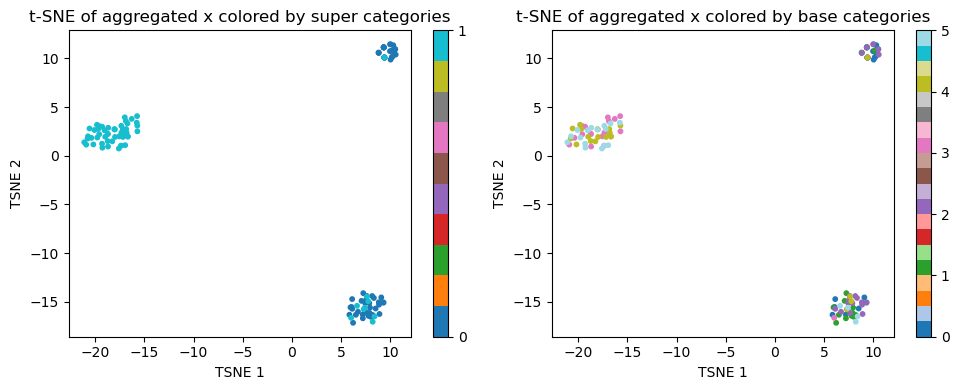

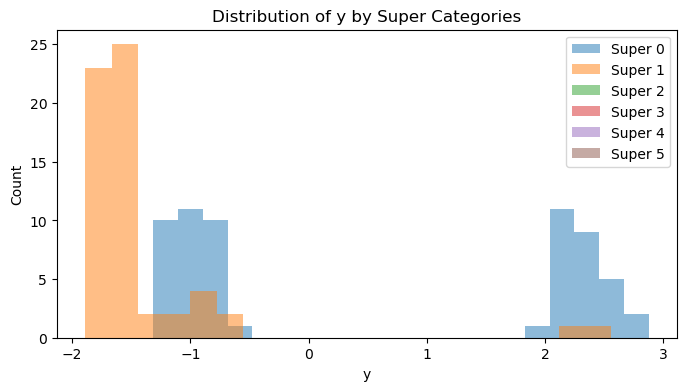

In [11]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg.numpy())

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(6):
    y_vals = data["y"][data["super_labels"] == super_id].numpy()
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


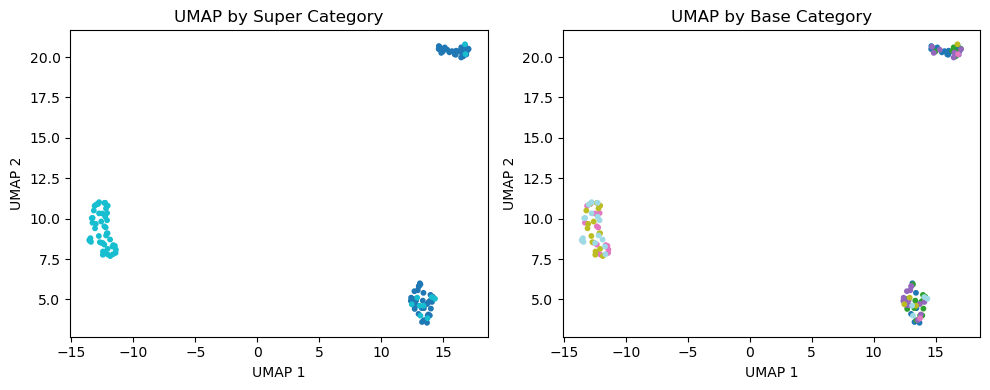

torch.Size([3, 2, 10])


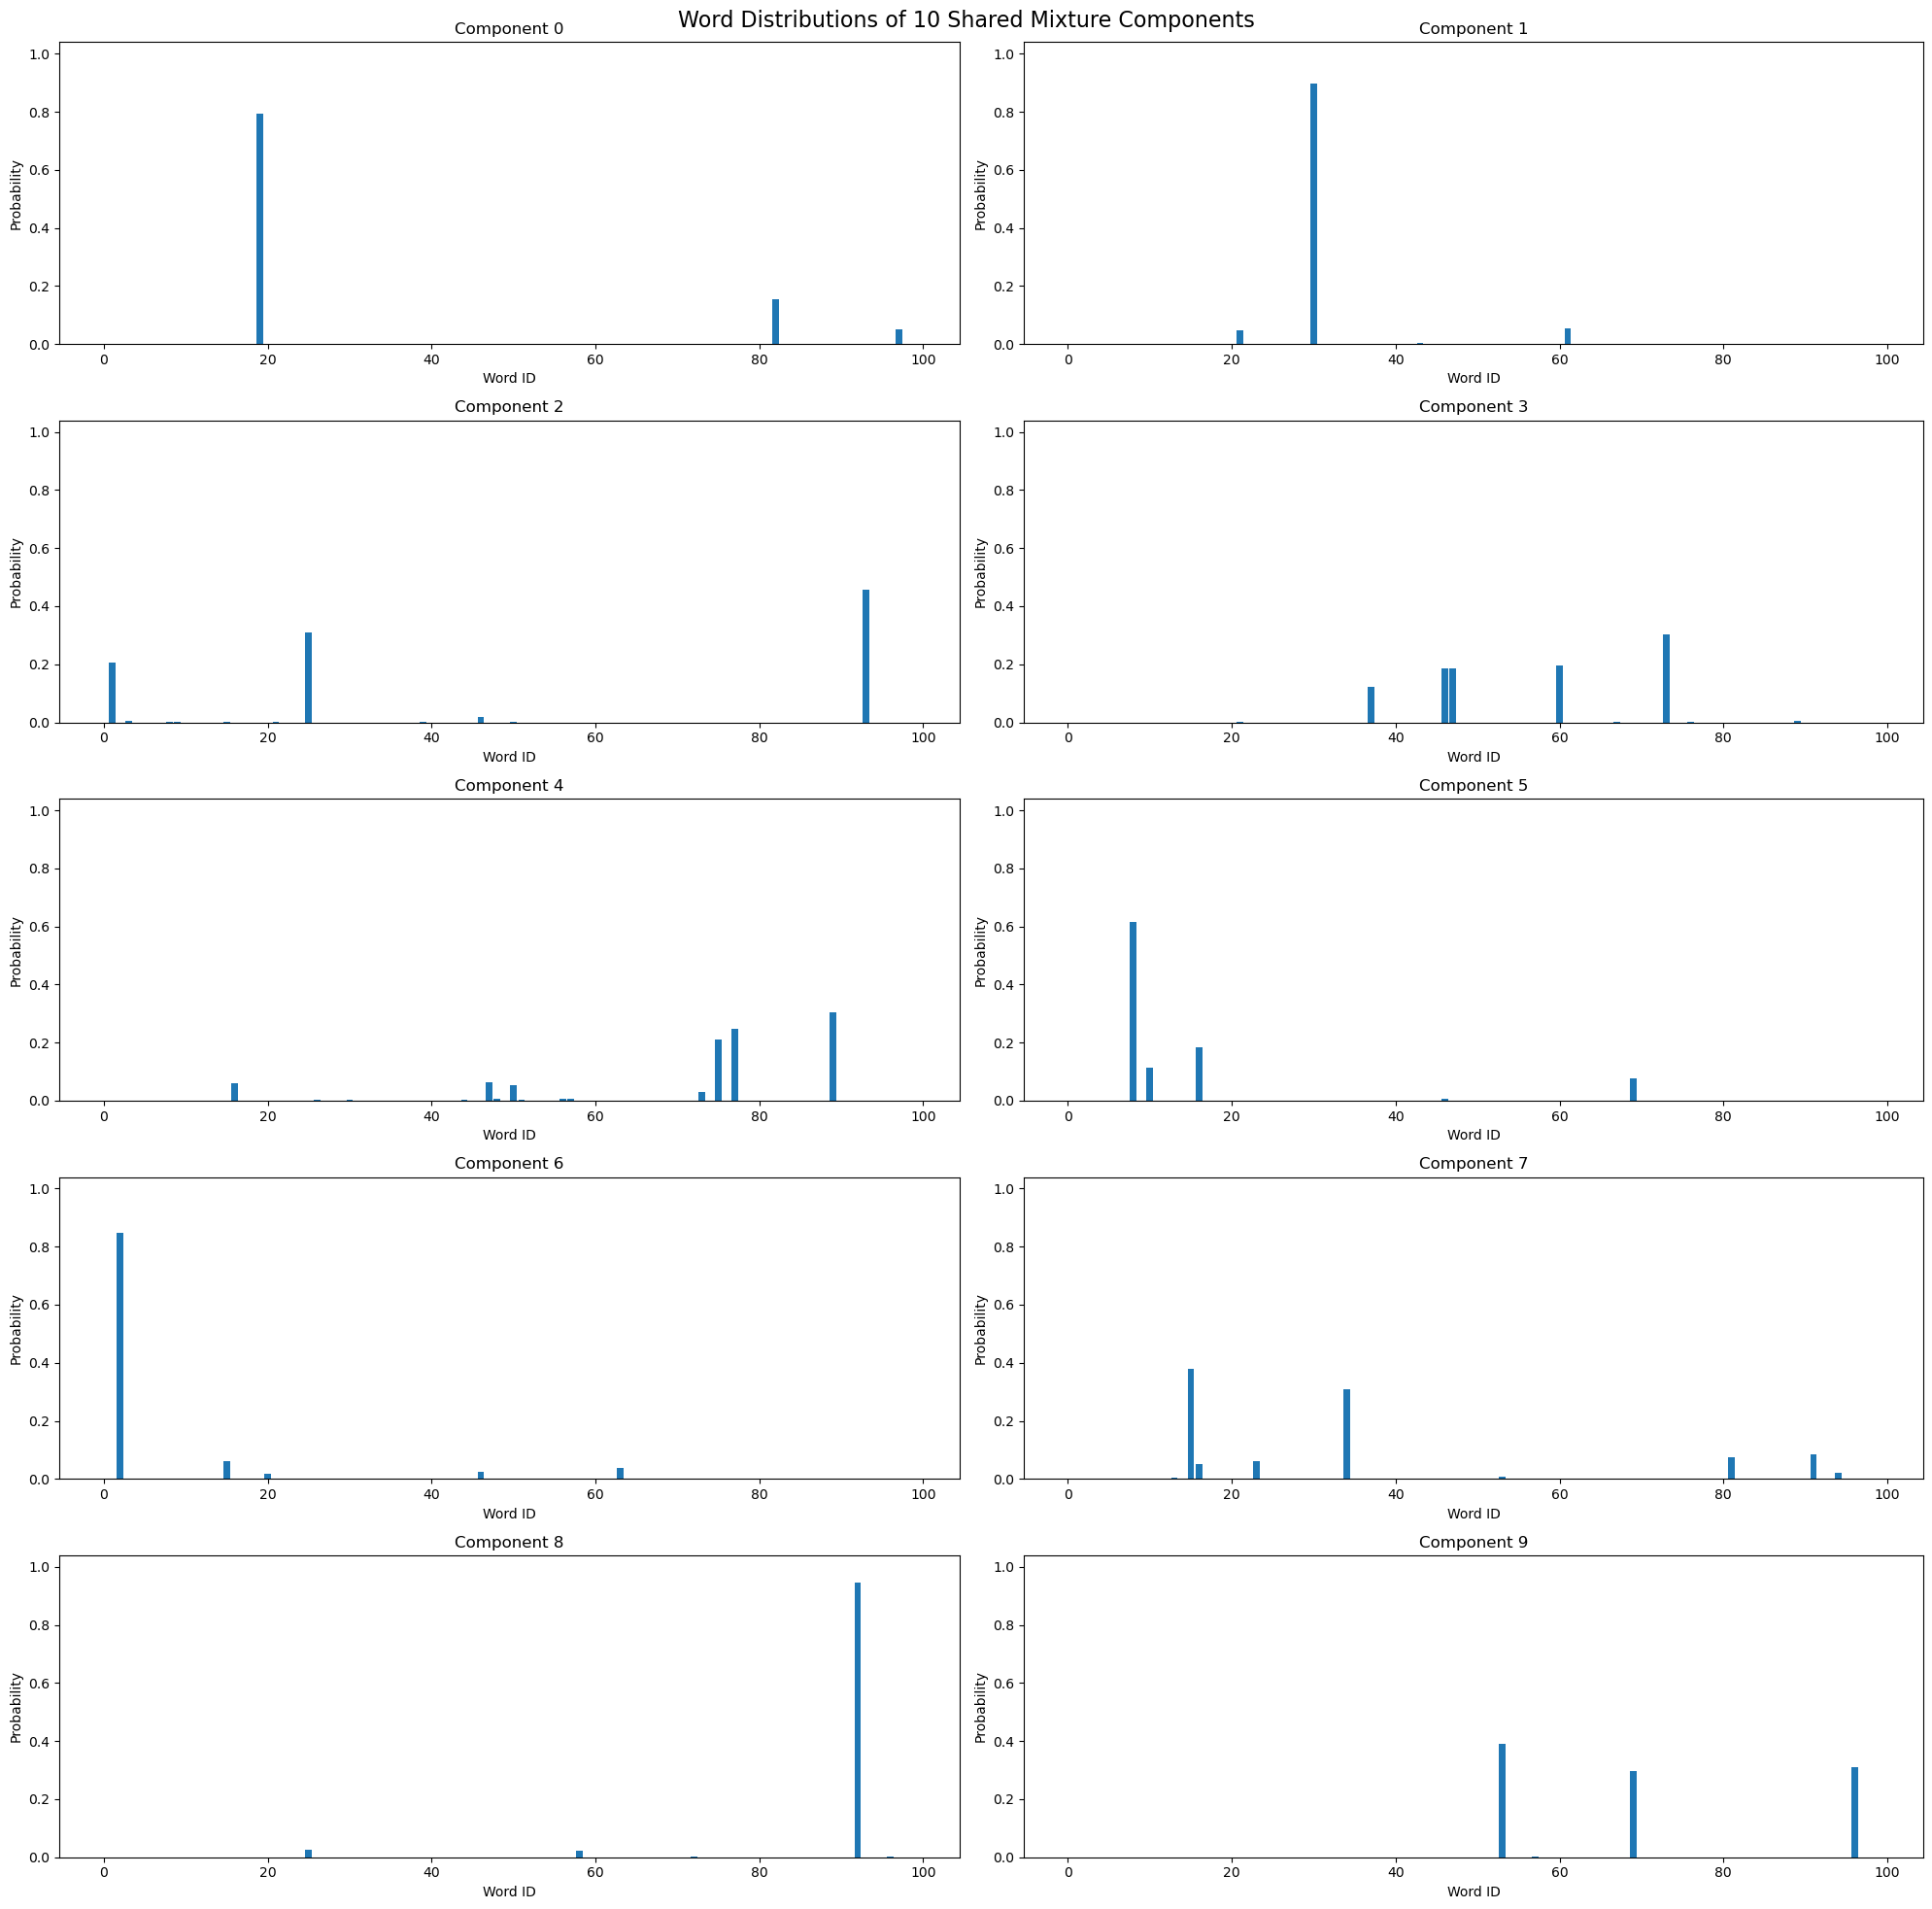

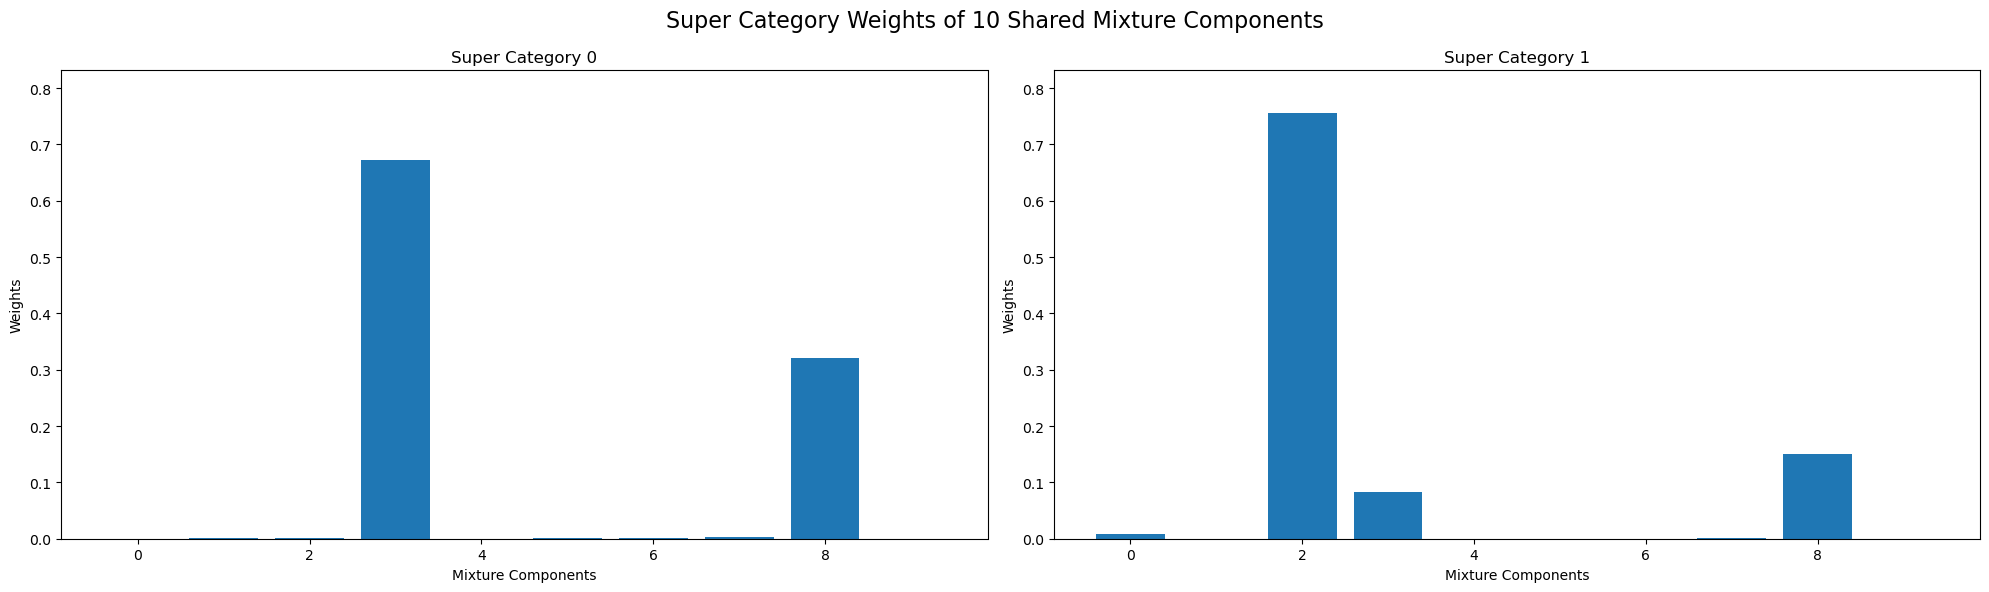

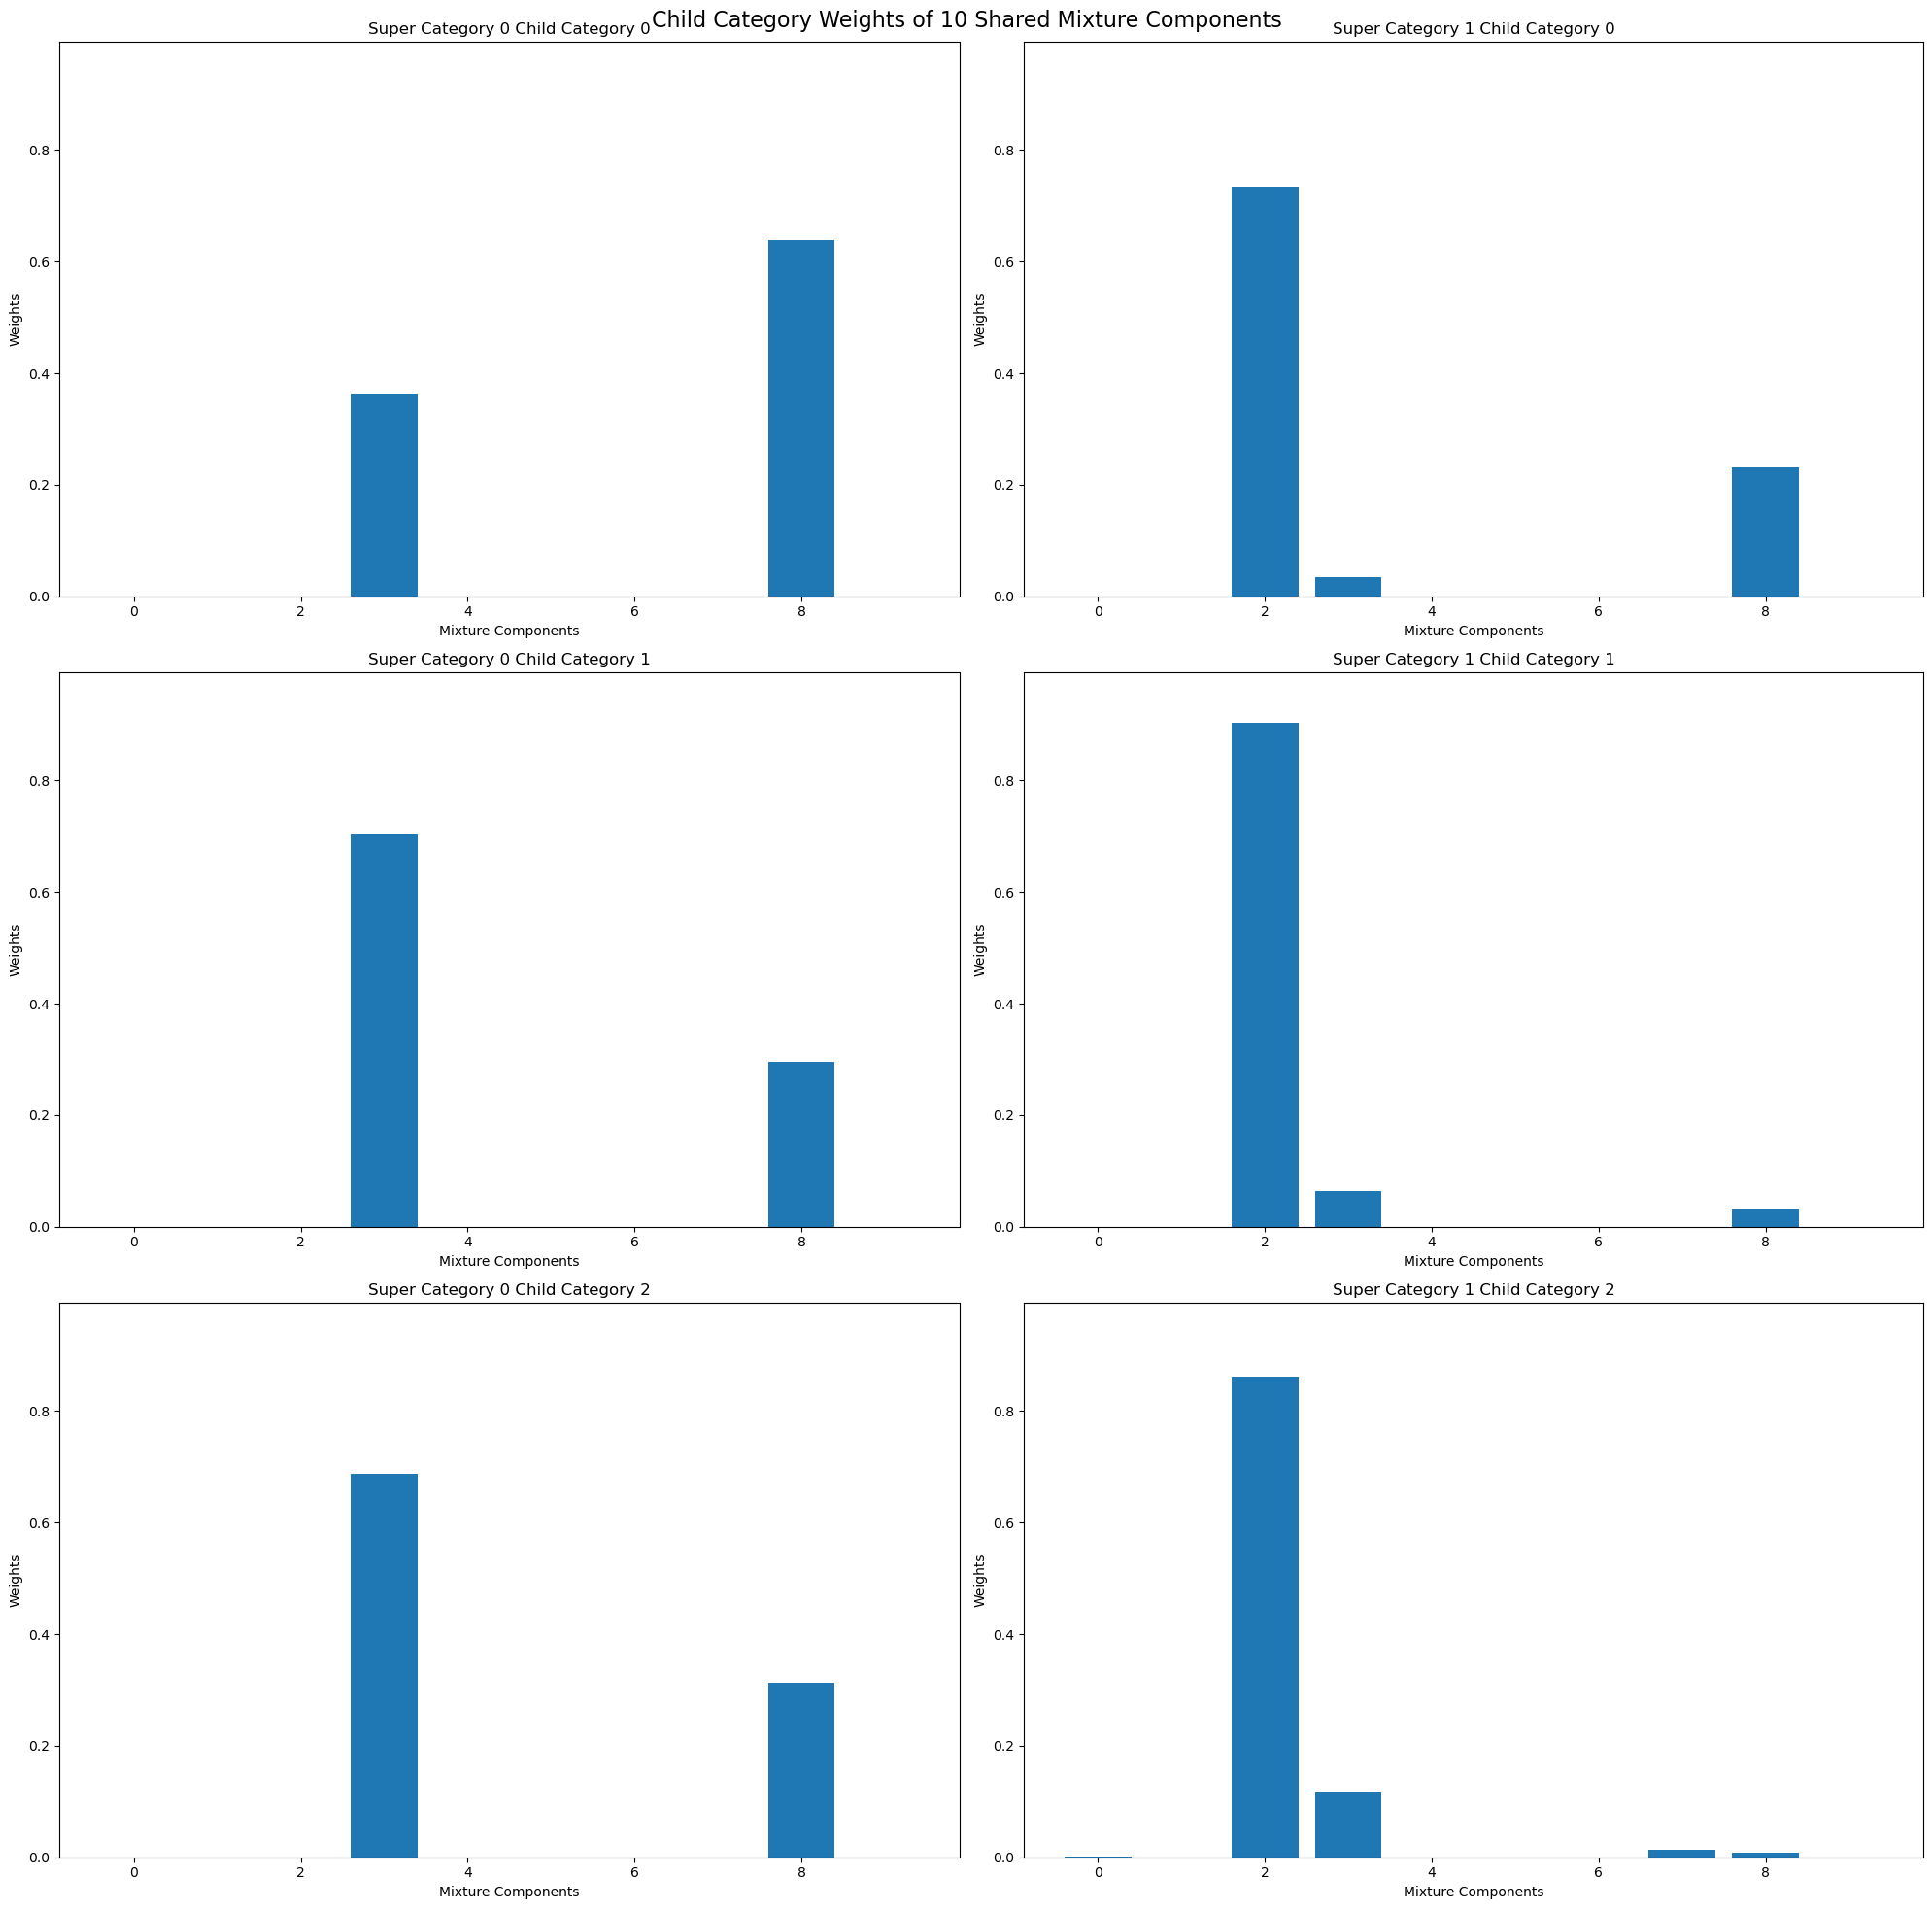

In [12]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg.numpy().astype(np.float32))


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = 10
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
print(child_mix_weights.shape)

# Bar plots for each component
fig, axs = plt.subplots(5, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i].numpy())
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(10), super_mix_weights[i].numpy())
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(3, 2, figsize=(20, 20))
for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        ax.bar(range(10), child_mix_weights[i][j].numpy())
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()



🔁 Round 1 / 10
📌 Optimizing guide...


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 0, loss = 36960.32


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/pyro/util.py:303: UserWarning: Found vars in model but not guide: {'z3'}
  warnings.warn(f"Found vars in model but not guide: {bad_sites}")


  [Guide] Step 100, loss = 36058.38
  [Guide] Step 200, loss = 35297.51
  [Guide] Step 300, loss = 33525.20
  [Guide] Step 400, loss = 31603.63
📌 Optimizing model...
  [Model] Step 0, loss = 29073.88
  [Model] Step 100, loss = 28271.47
  [Model] Step 200, loss = 26416.85
  [Model] Step 300, loss = 26033.10
  [Model] Step 400, loss = 26129.34

🔁 Round 2 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 24449.29
  [Guide] Step 100, loss = 25004.47
  [Guide] Step 200, loss = 22842.37
  [Guide] Step 300, loss = 23691.80
  [Guide] Step 400, loss = 23556.89
📌 Optimizing model...
  [Model] Step 0, loss = 23936.17
  [Model] Step 100, loss = 23236.78
  [Model] Step 200, loss = 20744.46
  [Model] Step 300, loss = 22058.52
  [Model] Step 400, loss = 21763.45

🔁 Round 3 / 10
📌 Optimizing guide...
  [Guide] Step 0, loss = 18566.46
  [Guide] Step 100, loss = 18515.62
  [Guide] Step 200, loss = 19447.17
  [Guide] Step 300, loss = 18361.74
  [Guide] Step 400, loss = 18880.67
📌 Optimizing model...
  

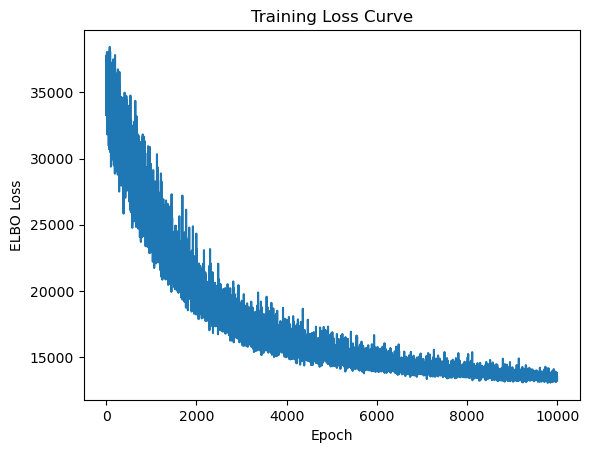

In [13]:
dataset = (data["x"], data["y"])
device = torch.device("cpu")
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
# Training settings
num_epochs = 1000
log_every = 100
lr = 1e-3

# Set up optimizer and ELBO
optim = pyro.optim.Adam({"lr": lr})

elbo = TraceEnum_ELBO(max_plate_nesting=1)
svi = SVI(model, guide, optim, loss=elbo)

# === Alternating training loop ===
num_rounds = 10
posterior_steps = 500
model_steps = 500
losses = []

for seed in range(0, 400, 100):
    pyro.clear_param_store()
    pyro.set_rng_seed(seed)

    # for epoch in range(num_epochs):
    #     pyro.clear_param_store()
    #     loss = svi.step(dataset, struct_upbd, vocab_size, device)
        
    #     losses.append(loss)
        
    #     if epoch % log_every == 0:
    #         print(f"Epoch {epoch:04d}  Loss: {loss:.4f}")
    #         optim.set_state({"lr": lr/(epoch+1)})
    for round_idx in range(num_rounds):
        print(f"\n🔁 Round {round_idx + 1} / {num_rounds}")
    
        # Phase 1: Guide (Posterior inference)
        set_requires_grad_by_prefix("model_", False)
        set_requires_grad_by_prefix("guide_", True)
        print("📌 Optimizing guide...")
        for step in range(posterior_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Guide] Step {step}, loss = {loss:.2f}")
    
        # Phase 2: Model (Generative parameter update)
        set_requires_grad_by_prefix("guide_", False)
        set_requires_grad_by_prefix("model_", True)
        print("📌 Optimizing model...")
        for step in range(model_steps):
            loss = svi.step(dataset, struct_upbd, vocab_size, device)
            losses.append(loss)
            if step % 100 == 0:
                print(f"  [Model] Step {step}, loss = {loss:.2f}")
    # Optional: plot loss
    try:
        import matplotlib.pyplot as plt
        plt.plot(losses)
        plt.xlabel("Epoch")
        plt.ylabel("ELBO Loss")
        plt.title("Training Loss Curve")
        plt.show()
    except ImportError:
        pass
    break



In [14]:
for name, value in pyro.get_param_store().items():
    print(f"{name}: {value}")


guide_beta_0_alpha: tensor([1.0532, 1.2439, 0.1685, 0.8094, 1.1124, 1.2029, 1.6825, 1.9155, 1.4386,
        1.1628], grad_fn=<AddBackward0>)
guide_beta_0_beta: tensor([3.9791, 4.1443, 0.5207, 2.0375, 2.7490, 3.8665, 3.2077, 3.0543, 1.8660,
        2.7788], grad_fn=<AddBackward0>)
guide_beta_1_alpha: tensor([0.8563, 1.1330, 1.7909, 1.8656, 0.9987, 0.2327, 1.2373, 0.5538, 0.2972,
        0.0383], grad_fn=<AddBackward0>)
guide_beta_1_beta: tensor([2.7082, 3.3930, 4.5548, 3.6243, 2.5125, 0.5712, 2.3098, 0.7577, 0.2670,
        0.1102], grad_fn=<AddBackward0>)
guide_beta_2_alpha: tensor([[1.3807e+00, 8.8532e-01, 1.2011e+00, 2.1652e+00, 8.7122e-01, 2.3879e+00,
         3.2804e+00, 2.9613e+00, 1.6728e+00, 1.6077e+00],
        [2.8051e-01, 1.9103e-01, 1.7222e-01, 1.2873e-01, 8.0737e-03, 2.5959e-03,
         5.0280e-02, 3.5200e-02, 3.2242e-02, 2.8377e-05]],
       grad_fn=<AddBackward0>)
guide_beta_2_beta: tensor([[6.6120e+00, 3.0029e+00, 4.0612e+00, 7.8307e+00, 2.6484e+00, 7.1297e+00,
        

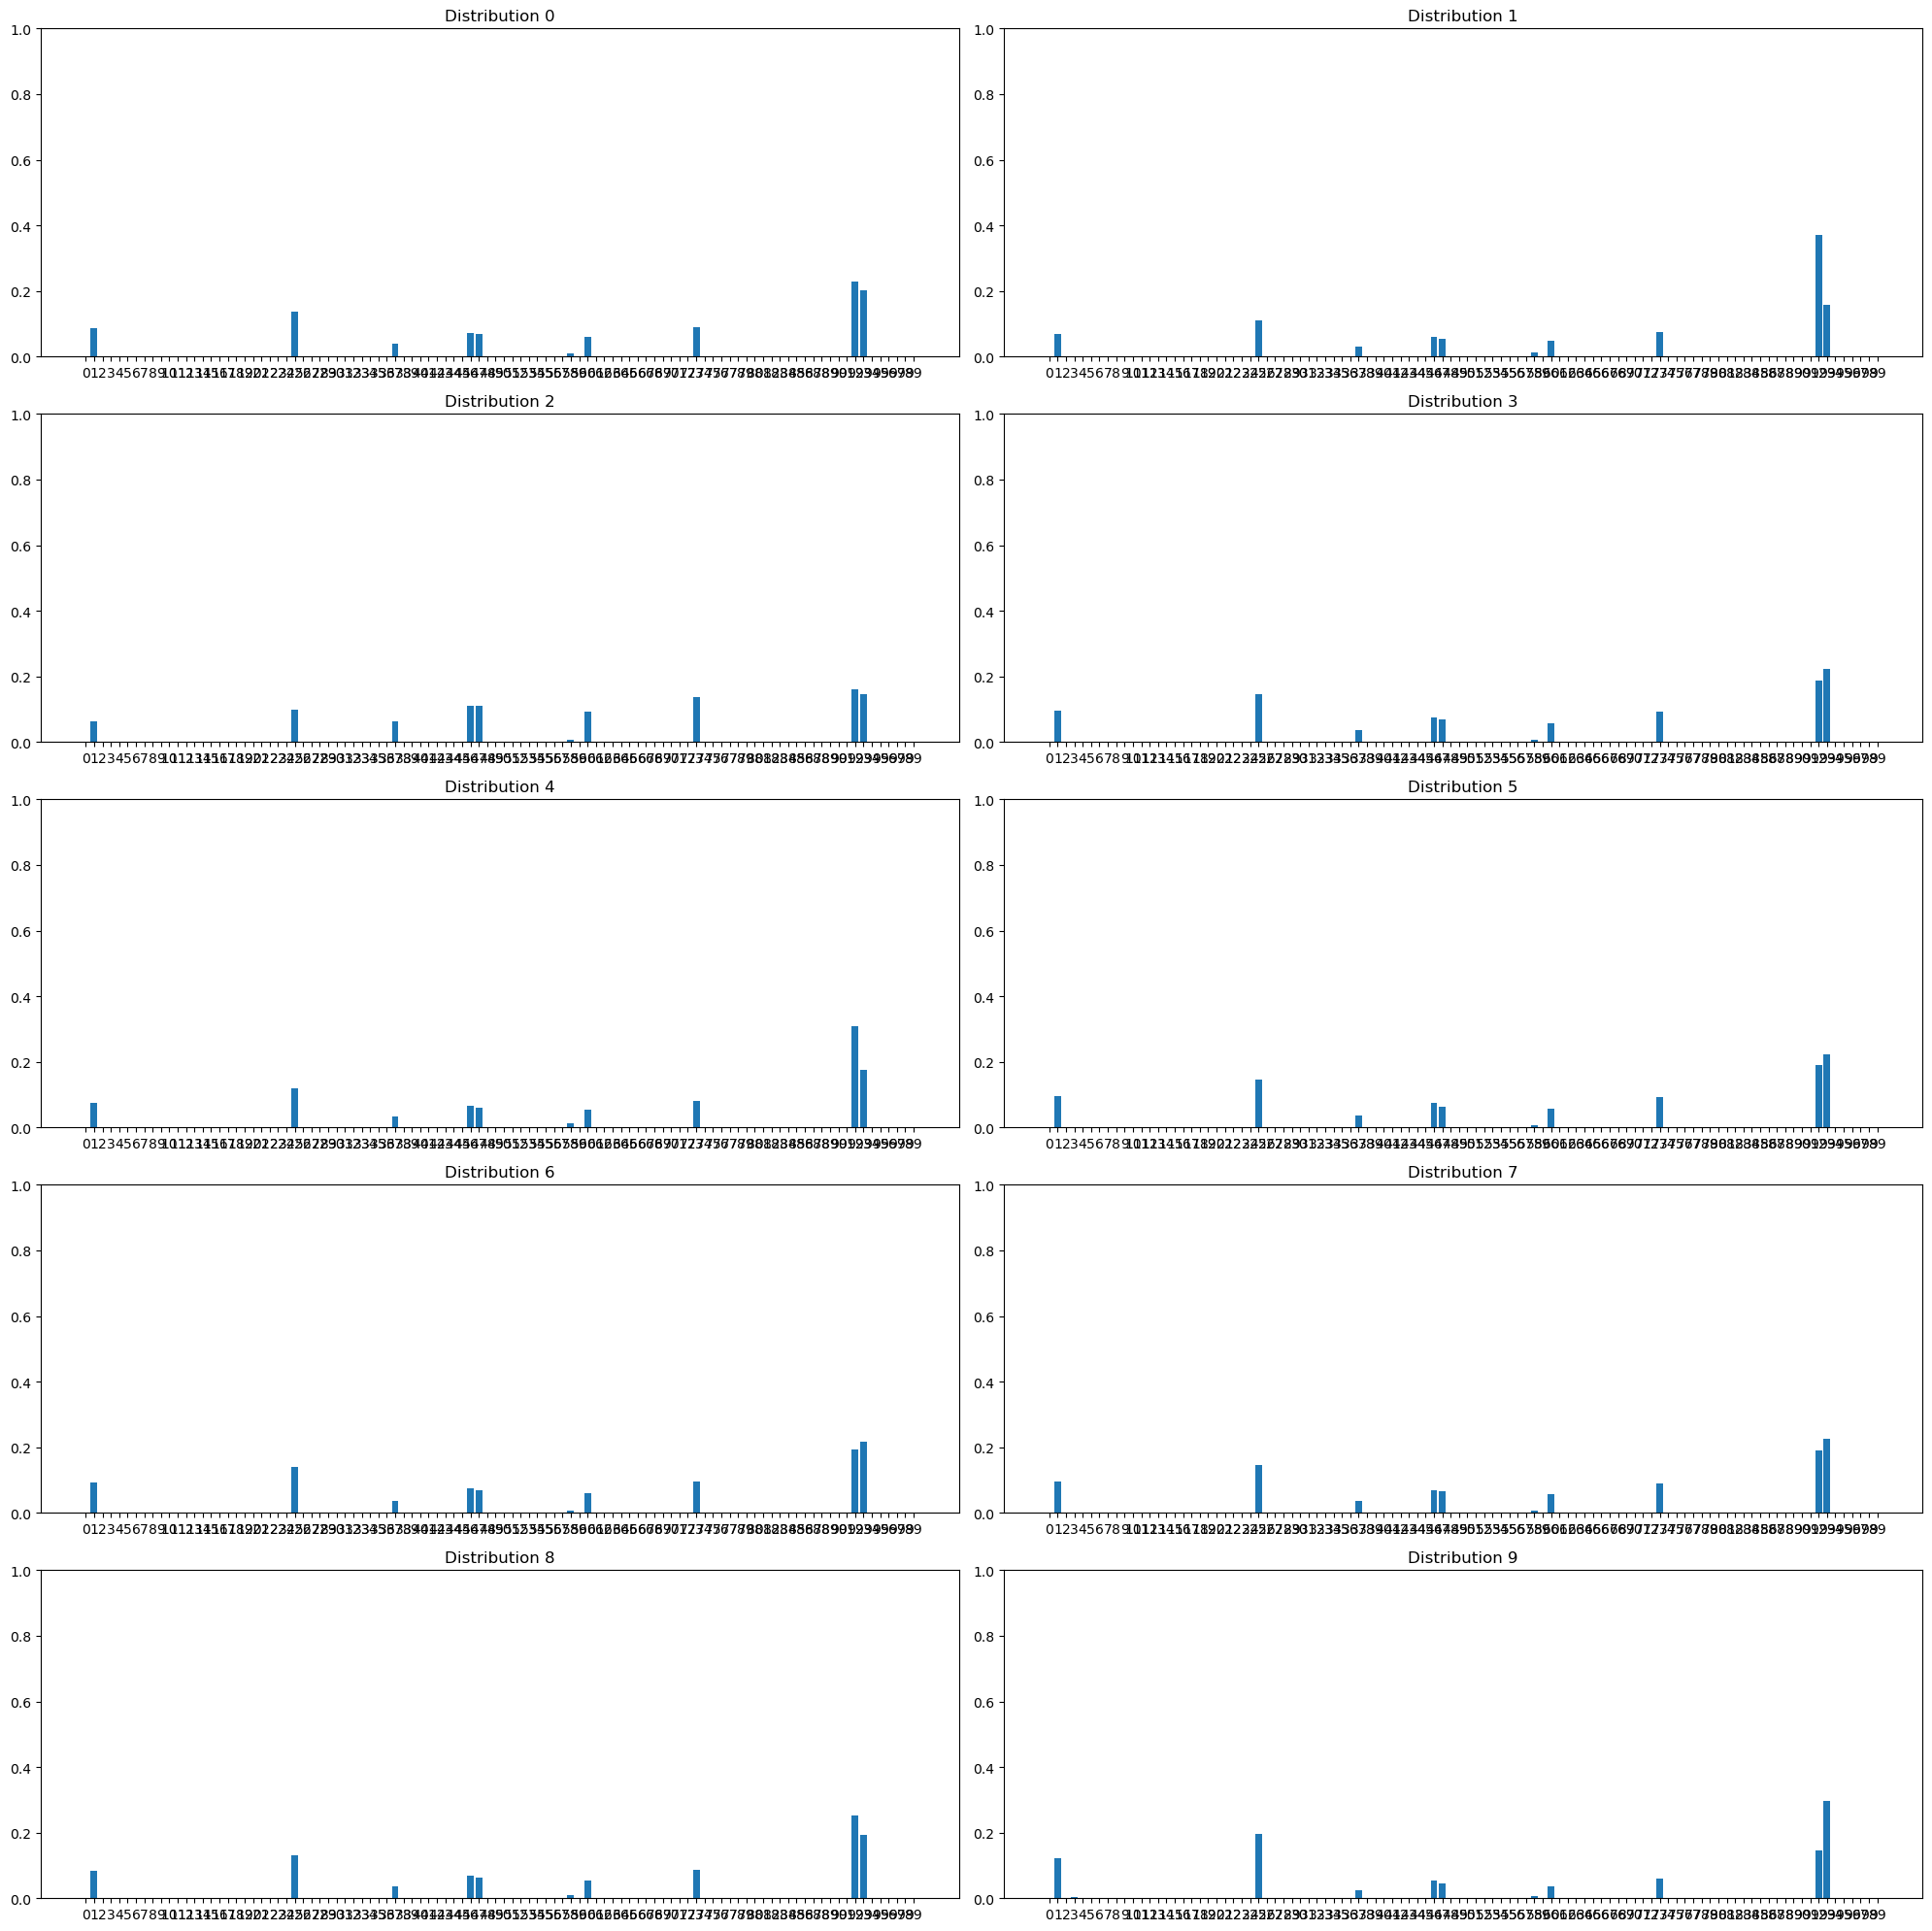

In [15]:
import torch
import matplotlib.pyplot as plt

# Example tensor: 10 distributions over 5 categories
params = pyro.get_param_store().get_param("model_phi_u").detach()

fig, axs = plt.subplots(5, 2, figsize=(20, 20))

for i in range(10):
    ax = axs[i // 2, i % 2]
    ax.bar(range(params.size(1)), params[i].cpu().numpy())
    ax.set_title(f'Distribution {i}')
    ax.set_xticks(range(params.size(1)))
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()


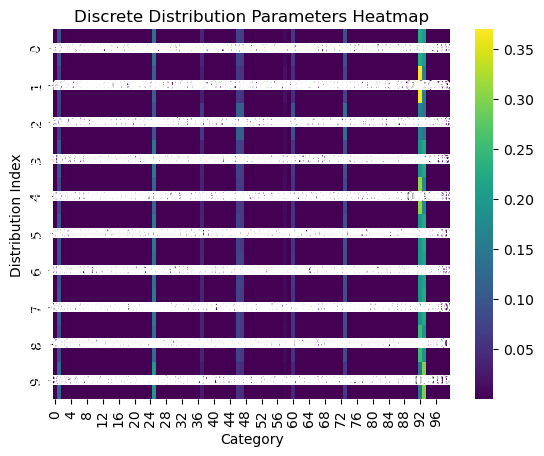

In [16]:
import seaborn as sns

sns.heatmap(params.numpy(), cmap='viridis', annot=True, cbar=True)
plt.xlabel("Category")
plt.ylabel("Distribution Index")
plt.title("Discrete Distribution Parameters Heatmap")
plt.show()


In [17]:
import torch
import torch.nn.functional as F

# Simulated inputs

true_params = data["word_dists"]
candidate_params = pyro.get_param_store().get_param("model_phi_u").detach()
print(true_params.shape)
print(candidate_params.shape)

# Normalize to make them valid distributions
true_params /= true_params.sum(dim=1, keepdim=True)
candidate_params /= candidate_params.sum(dim=1, keepdim=True)
assert torch.allclose(true_params.sum(dim=1), torch.ones_like(true_params.sum(dim=1)), atol=1e-4)
assert torch.allclose(candidate_params.sum(dim=1), torch.ones_like(candidate_params.sum(dim=1)), atol=1e-4)


# Compute Jensen-Shannon distance between all pairs
# def jensen_shannon(p, q, eps=1e-8):
#     # Normalize inputs to ensure valid distributions
#     p = p / (p.sum(dim=-1, keepdim=True) + eps)
#     q = q / (q.sum(dim=-1, keepdim=True) + eps)
#     m = 0.5 * (p + q)

#     # Compute KL divergences: kl_div expects log-prob as input
#     kl_pm = F.kl_div((p + eps).log(), m, reduction='none').sum(-1)
#     kl_qm = F.kl_div((q + eps).log(), m, reduction='none').sum(-1)

#     return 0.5 * (kl_pm + kl_qm)
def jensen_shannon(p, q, eps=1e-8):
    p = p / (p.sum(dim=-1, keepdim=True) + eps)
    q = q / (q.sum(dim=-1, keepdim=True) + eps)
    m = 0.5 * (p + q)

    kl_pm = (p * ((p + eps).log() - (m + eps).log())).sum(-1)
    kl_qm = (q * ((q + eps).log() - (m + eps).log())).sum(-1)

    return 0.5 * (kl_pm + kl_qm)
# Expand for broadcasting: (6, 1, K) and (1, 20, K) → (6, 20, K)
p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)


torch.Size([10, 100])
torch.Size([10, 100])
tensor([[0.3079, 0.3081, 0.3079, 0.3077, 0.3076, 0.3085, 0.3086, 0.3089, 0.3100,
         0.3087],
        [0.3093, 0.3089, 0.3093, 0.3088, 0.3086, 0.3087, 0.3099, 0.3098, 0.3097,
         0.3094],
        [0.7636, 0.7057, 0.6889, 0.7860, 0.7298, 0.7873, 0.7776, 0.7887, 0.7537,
         0.8619],
        [0.6780, 0.6350, 0.7926, 0.6786, 0.6544, 0.6742, 0.6835, 0.6704, 0.6647,
         0.5947],
        [0.3914, 0.3844, 0.4101, 0.3964, 0.3880, 0.3909, 0.3931, 0.3909, 0.3910,
         0.3777],
        [0.3219, 0.3209, 0.3229, 0.3229, 0.3228, 0.3226, 0.3230, 0.3221, 0.3232,
         0.3213],
        [0.3465, 0.3435, 0.3527, 0.3478, 0.3476, 0.3474, 0.3473, 0.3460, 0.3477,
         0.3423],
        [0.3102, 0.3102, 0.3100, 0.3123, 0.3119, 0.3121, 0.3113, 0.3109, 0.3119,
         0.3117],
        [0.6414, 0.7444, 0.5772, 0.6059, 0.7026, 0.6101, 0.6127, 0.6105, 0.6612,
         0.5695],
        [0.3087, 0.3095, 0.3086, 0.3086, 0.3086, 0.3096, 0.3100, 

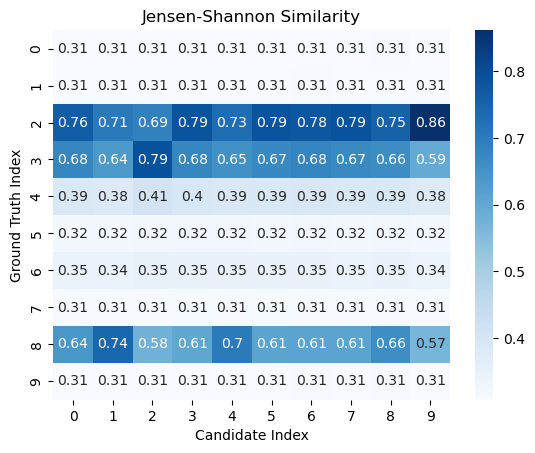

In [18]:
# import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()


In [19]:
# # Initialize parameters
param_dims = list(struct_upbd.values())
param_dims.reverse()

struct_params = {}
# dimension: number of mixture
struct_params["alpha0"] = pyro.get_param_store().get_param("model_alpha0").detach()
# dimension: number of mixture
struct_params["alpha1"] = pyro.get_param_store().get_param("model_alpha1").detach()

for i in range(2, len(struct_upbd)+1, 1):
    # dimension: level i category * level i-1 category * ... * level 1 category * number of mixture
    struct_params[f"alpha{i}"] = pyro.get_param_store().get_param(f"model_alpha{i}").detach().unsqueeze(-1)
# dimension: number of mixture * vocabulary size
gen_params = pyro.get_param_store().get_param("model_phi_u").detach()
# dimension: number of mixture * 1
reg_params_mu = pyro.get_param_store().get_param("model_phi_y_mu").detach()
# dimension: number of mixture * 1
reg_params_sigma = pyro.get_param_store().get_param("model_phi_y_sigma").detach()

struct_weights = {}
# dimension: number of mixture
beta_0 = pyro.sample("G0", dist.Beta(torch.ones([struct_upbd["G0"]], device=device), struct_params["alpha0"]).to_event(1))
# dimension: number of mixture
struct_weights["G0"] = mix_weights(beta_0)[..., :-1]
for level in range(1, len(struct_upbd), 1):
    # dimension: level level category * level level-1 category * ... * level 1 category * number of mixture
    param_alpha = struct_params[f"alpha{level}"]*struct_weights[f"G{level-1}"]
    param_beta = struct_params[f"alpha{level}"]*(1 - struct_weights[f"G{level-1}"].cumsum(-1))
    with pyro.plate(f"LoG{level}", struct_upbd[f"G{level}"]):
        # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
        beta = pyro.sample(f"G{level}", dist.Beta(param_alpha.unsqueeze(0).expand(param_dims[-level-1:]), param_beta.unsqueeze(0).expand(param_dims[-level-1:])).to_event(level))
    # dimension: level level+1 category * level level category * level level-1 category * ... * level 1 category * number of mixture
    struct_weights[f"G{level}"] = mix_weights(beta)[..., :-1]

assign_prior = {}
# dimension: number of level - 1
etas = torch.distributions.Gamma(torch.tensor(1.0, device=device), torch.tensor(1.0, device=device)).sample((len(struct_upbd)-1,))
for level in range(1, len(struct_upbd), 1):
    params_shape = param_dims[-level-1:-1]
    params_shape.reverse()
    # dimension: level 1 category * level 2 category * ... * level level category
    assign_prior[f"LoZ{level}"] = pyro.param(f"model_LoZ{level}", torch.distributions.Dirichlet(torch.ones(struct_upbd[f"G{level}"], device=device)).sample(params_shape[:-1]), constraint=constraints.simplex)

In [20]:
struct_weights

{'G0': tensor([0.3467, 0.2514, 0.0012, 0.0980, 0.0501, 0.0096, 0.0156, 0.0058, 0.0642,
         0.0905]),
 'G1': tensor([[2.5033e-01, 5.0302e-01, 1.0000e-06, 6.9476e-02, 2.1163e-03, 1.0000e-06,
          1.9648e-02, 1.0000e-06, 9.5455e-04, 1.2102e-01],
         [4.6863e-01, 2.4133e-01, 1.0000e-06, 5.5951e-02, 1.0000e-06, 1.3904e-04,
          1.0000e-06, 1.0000e-06, 2.2577e-01, 7.7912e-03]]),
 'G2': tensor([[[1.9560e-01, 6.5522e-01, 1.0000e-06, 8.9442e-03, 1.0000e-06,
           1.0000e-06, 1.0000e-06, 1.0000e-06, 1.0590e-04, 9.5317e-02],
          [7.8694e-01, 3.2443e-02, 9.9999e-07, 9.9999e-07, 9.9999e-07,
           9.9999e-07, 9.9999e-07, 9.9999e-07, 1.8061e-01, 9.9999e-07]],
 
         [[2.4833e-01, 6.8826e-01, 9.9999e-07, 2.5354e-02, 9.9999e-07,
           9.9999e-07, 1.3417e-04, 9.9999e-07, 9.9999e-07, 3.4902e-02],
          [6.2904e-01, 2.1092e-01, 9.9999e-07, 5.0332e-02, 9.9999e-07,
           9.9999e-07, 9.9999e-07, 9.9999e-07, 1.0970e-01, 9.9999e-07]],
 
         [[3.9066e-0

In [21]:
print(struct_weights["G2"].shape)
selected = struct_weights["G2"].view(-1, 10)
print(selected.shape)

torch.Size([3, 2, 10])
torch.Size([6, 10])


In [22]:
selected = selected/selected.sum(dim=-1, keepdim=True)

In [23]:
struct_weights["G2"].view(-1, 10)

tensor([[1.9560e-01, 6.5522e-01, 1.0000e-06, 8.9442e-03, 1.0000e-06, 1.0000e-06,
         1.0000e-06, 1.0000e-06, 1.0590e-04, 9.5317e-02],
        [7.8694e-01, 3.2443e-02, 9.9999e-07, 9.9999e-07, 9.9999e-07, 9.9999e-07,
         9.9999e-07, 9.9999e-07, 1.8061e-01, 9.9999e-07],
        [2.4833e-01, 6.8826e-01, 9.9999e-07, 2.5354e-02, 9.9999e-07, 9.9999e-07,
         1.3417e-04, 9.9999e-07, 9.9999e-07, 3.4902e-02],
        [6.2904e-01, 2.1092e-01, 9.9999e-07, 5.0332e-02, 9.9999e-07, 9.9999e-07,
         9.9999e-07, 9.9999e-07, 1.0970e-01, 9.9999e-07],
        [3.9066e-01, 5.5890e-01, 1.0000e-06, 2.5752e-02, 1.0000e-06, 1.0000e-06,
         8.6627e-05, 1.0000e-06, 1.0000e-06, 2.3836e-02],
        [8.7395e-01, 3.8428e-02, 9.9999e-07, 3.3443e-06, 9.9999e-07, 9.9999e-07,
         9.9999e-07, 9.9999e-07, 8.7610e-02, 9.9999e-07]])

In [24]:
selected.shape

torch.Size([6, 10])

tensor([[0.3292, 0.5229, 0.3538, 0.5392, 0.3542, 0.4405],
        [0.3197, 0.4491, 0.3283, 0.4436, 0.3285, 0.4017],
        [0.3323, 0.4650, 0.3620, 0.5177, 0.3626, 0.4099],
        [0.3217, 0.3526, 0.3341, 0.3847, 0.3343, 0.3423],
        [0.3322, 0.4688, 0.3617, 0.5196, 0.3623, 0.4120],
        [0.3265, 0.3274, 0.3430, 0.3762, 0.3435, 0.3245]])


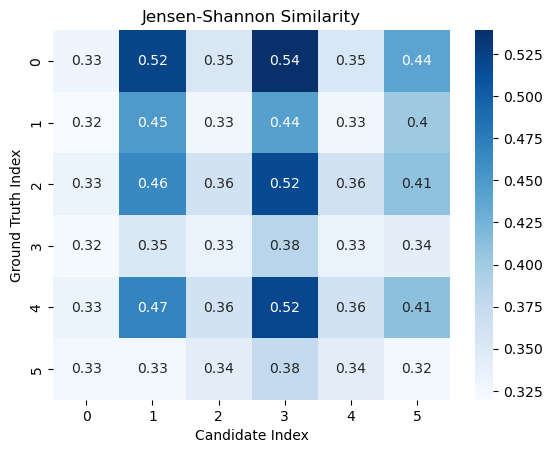

In [25]:
true_params = data["child_mix_weights"].view(-1, 10)
candidate_params = selected

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

tensor([[1.0000, 0.6167, 0.9399, 0.4621, 0.9457, 0.4617],
        [0.6167, 1.0000, 0.5567, 0.9511, 0.5610, 0.9166],
        [0.9399, 0.5567, 1.0000, 0.4704, 0.9998, 0.4933],
        [0.4621, 0.9511, 0.4704, 1.0000, 0.4705, 0.9878],
        [0.9457, 0.5610, 0.9998, 0.4705, 1.0000, 0.4922],
        [0.4617, 0.9166, 0.4933, 0.9878, 0.4922, 1.0000]])


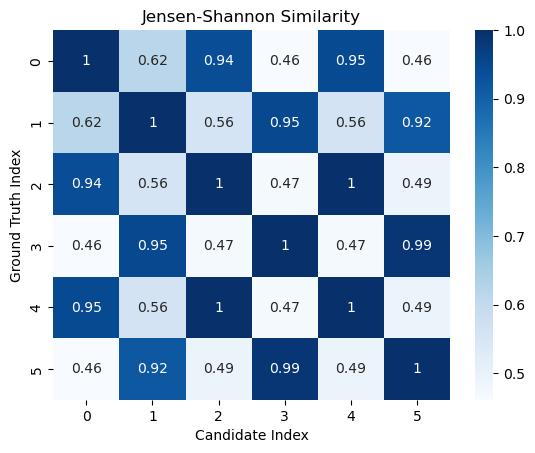

In [26]:
true_params = data["child_mix_weights"].view(-1, 10)
candidate_params = true_params

p_exp = true_params[:, None, :]  # shape [6, 1, K]
q_exp = candidate_params[None, :, :]  # shape [1, 20, K]

# JS similarity matrix: shape [6, 20]
js_matrix = jensen_shannon(p_exp, q_exp)

# Optional: convert to similarity score (1 - distance)
similarity = 1 - js_matrix

print(similarity)

sns.heatmap(similarity.numpy(), annot=True, cmap='Blues')
plt.xlabel("Candidate Index")
plt.ylabel("Ground Truth Index")
plt.title("Jensen-Shannon Similarity")
plt.show()

In [27]:
from pyro.infer import Predictive

# guide: your trained guide
# model: your model without obs
# num_samples: number of predictive samples

predictive = Predictive(model, guide=guide, num_samples=1000)

# Omit `data` or provide partial input depending on your model
samples = predictive((dataset[0].to(device), None),struct_upbd, vocab_size, device)  # or data=..., depending on your model's inputs

In [28]:
predict = samples['y'].mean(dim=0)
predict_var = samples['y'].var(dim=0)

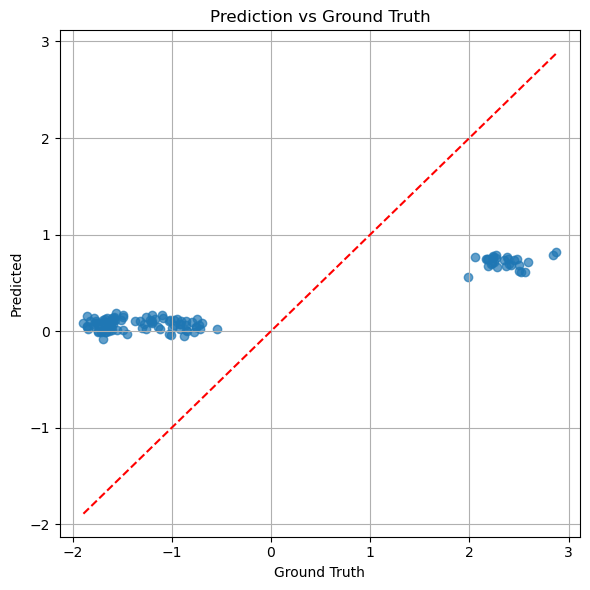

In [29]:
y_true = dataset[1]     # ground truth
y_pred = predict # predicted (with noise)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')  # y = x line
plt.xlabel("Ground Truth")
plt.ylabel("Predicted")
plt.title("Prediction vs Ground Truth")
plt.grid(True)
plt.tight_layout()
plt.show()

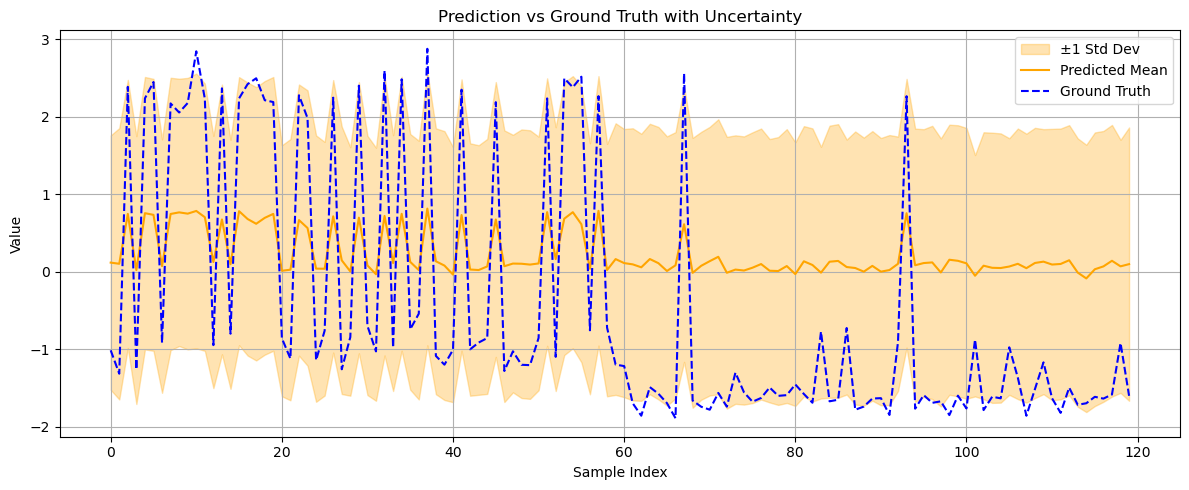

In [30]:

# Example data
N=120
mean_pred = y_pred
var_pred = predict_var

std_pred = var_pred.sqrt()
x = torch.arange(N)

plt.figure(figsize=(12, 5))

# Confidence interval (±1 std)
plt.fill_between(x, mean_pred - std_pred, mean_pred + std_pred, color="orange", alpha=0.3, label="±1 Std Dev")

# Prediction mean
plt.plot(x, mean_pred, color="orange", label="Predicted Mean")

# Ground truth
plt.plot(x, y_true, color="blue", linestyle="--", label="Ground Truth")

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Prediction vs Ground Truth with Uncertainty")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()